# Autoemcoder metrics (amomaly detector)

In [1]:
import os
os.chdir('..')

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, LeakyReLU, BatchNormalization, Lambda, Concatenate
from tensorflow.keras.models import Model,load_model
from tensorflow.keras import optimizers
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing import image
from tensorflow.keras.losses import binary_crossentropy 

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from scripts.load_data import load_data

In [3]:
n_test,train_smile,train_nonSmile,test_smile,test_nonSmile=load_data()

test_features=np.concatenate((test_smile, test_nonSmile), axis=0)
test_labels=np.concatenate((np.full(n_test, "smile"), np.full(n_test, "non-smile")))

idxs = np.random.choice(n_test*2, size=n_test*2, replace=False)
test_features = test_features[idxs,:,:,:]
test_labels = test_labels[idxs]

In [9]:
def combined_loss(y_true, y_pred):
    bce = binary_crossentropy(y_true, y_pred)

    brightness = tf.reduce_mean(y_true, axis=-1, keepdims=True)
    weighted=brightness**2
    weighted_error = tf.abs(y_true - y_pred) * (1 + 2 * weighted)

    l1 = tf.reduce_mean(weighted_error)
    return 0.0*bce + 1.0*l1

def add_sobel_channels(x):
    edges = tf.image.sobel_edges(x)
    shape = tf.shape(edges)
    edges = tf.reshape(edges, (shape[0], shape[1], shape[2], 6))
    return edges

autoencoder = load_model("model/autoencoder1.keras",custom_objects={"combined_loss": combined_loss,"add_sobel_channels": add_sobel_channels})

In [ ]:
def smile_detector(features,threshold=0.08):
    predictions = autoencoder.predict(features)
    errors = combined_loss(features,predictions).numpy()
    labels_predictions = np.where(np.array(errors) > threshold, "smile", "non-smile")
    return labels_predictions

In [28]:
labels_predictions=smile_detector(np.expand_dims(test_features[0], axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


In [34]:
labels_predictions=smile_detector(test_features)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


In [35]:
print(accuracy_score(test_labels, labels_predictions))

0.6041666666666666


['non-smile']


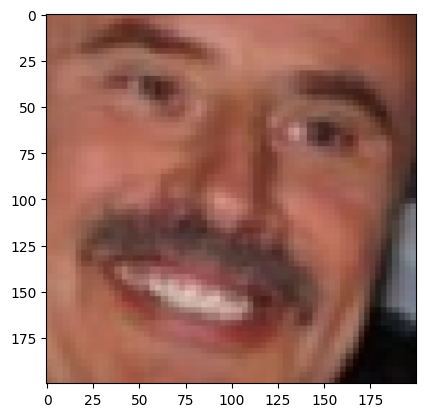

In [29]:
print(labels_predictions)
plt.imshow(test_features[0].reshape(test_features.shape[1], test_features.shape[2], test_features.shape[3]))

In [30]:
def compare_predictions(feature):
    label_prediction=smile_detector(np.expand_dims(feature, axis=0))
    print(label_prediction)
    plt.imshow(feature)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
['smile']


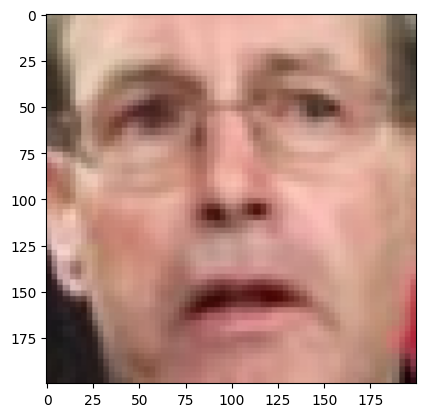

In [32]:
compare_predictions(test_features[1])